# Aprendizaje No Supervisado, Semi-supervisado y Activo

Este cuadernillo explora tres paradigmas de aprendizaje automático de forma progresiva:

1. **No supervisado**: agrupamiento con K-Means sobre datos sintéticos.
2. **Semi-supervisado**: clasificación de imágenes aéreas usando una pequeña fracción de etiquetas.
3. **Activo**: refinamiento del modelo semi-supervisado mediante selección estratégica de muestras a etiquetar.

---

## Parte 1: Aprendizaje No Supervisado con K-Means

### Importación de librerías

Se importan las herramientas necesarias para generación de datos, clustering, evaluación de métricas y visualización.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib as mpl
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib.ticker import FixedLocator, FixedFormatter

### 1. Generación del Dataset Sintético

Se genera un dataset bidimensional con `make_blobs`, cuyo número de clusters ($k_{real}$) se elige aleatoriamente en el rango $[1, 20]$. Los centros de los clusters se distribuyen uniformemente en $[-10, 10]^2$ con desviación estándar fija de 1.0.

El uso de datos sintéticos permite controlar el ground truth, lo que facilita evaluar con precisión cuánto se acercan los métodos de estimación al valor real de $k$.

In [3]:
def generar_dataset_dinamico(min_k=1, max_k=20):
    n_clusters_random = np.random.randint(min_k, max_k + 1)
    blob_centers = np.random.uniform(-10, 10, (n_clusters_random, 2))
    blob_std = np.full(n_clusters_random, 1.0)

    X, y = make_blobs(n_samples=2000, centers=blob_centers,
                      cluster_std=blob_std, random_state=42)
    return X, n_clusters_random

X, k_real = generar_dataset_dinamico()
print(f"Clusters reales generados: {k_real}")

Clusters reales generados: 13


### 2. Estimación del $k$ Óptimo: Método del Codo y Coeficiente de Silueta

Se entrena K-Means para valores de $k$ entre 2 y 20 y se registran dos métricas:

**Método del Codo (Elbow Method)**
Evalúa la inercia (suma de distancias cuadráticas al centroide más cercano) en función de $k$. A medida que $k$ aumenta, la inercia decrece monótonamente, pero la tasa de mejora se reduce. El "codo" es el punto donde la relación entre mejoras consecutivas cae más abruptamente:

$$\text{ratio}_i = \frac{\Delta \text{inercia}_{i+1}}{\Delta \text{inercia}_i}$$

El $k$ óptimo se estima como el valor donde este ratio es mínimo.

**Coeficiente de Silueta**
Mide la cohesión interna y separación entre clusters. Para cada muestra $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))}$$

donde $a(i)$ es la distancia media a los puntos del mismo cluster y $b(i)$ es la distancia media al cluster vecino más cercano. El valor varía en $[-1, 1]$; cuanto mayor, mejor la partición. El $k$ óptimo es el que maximiza el score promedio.

In [4]:
inercias = []
silhouette_scores = []
rango_k = range(2, 21)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(X)

    inercias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# Método del codo (aproximado)
mejoras = np.diff(inercias)

# Cambio relativo (qué tanto mejora respecto al anterior)
ratios = mejoras[1:] / mejoras[:-1]

# El codo es donde la mejora cae drásticamente
k_codo = rango_k[np.argmin(ratios) + 1]

# Mejor k por silhouette
k_silhouette = rango_k[np.argmax(silhouette_scores)]

print("\n--- Comparación de clusters ---")
print(f"k real: {k_real}")
print(f"k estimado (silhouette): {k_silhouette}")
print(f"k estimado (codo): {k_codo}")


--- Comparación de clusters ---
k real: 13
k estimado (silhouette): 6
k estimado (codo): 3


### 3. Visualización del Dataset y el Método del Codo

Se grafican el dataset original y la curva de inercia. La línea roja vertical indica el $k$ estimado por el Método del Codo. Visualmente se puede comparar si el punto de inflexión coincide con la estructura real del dataset.

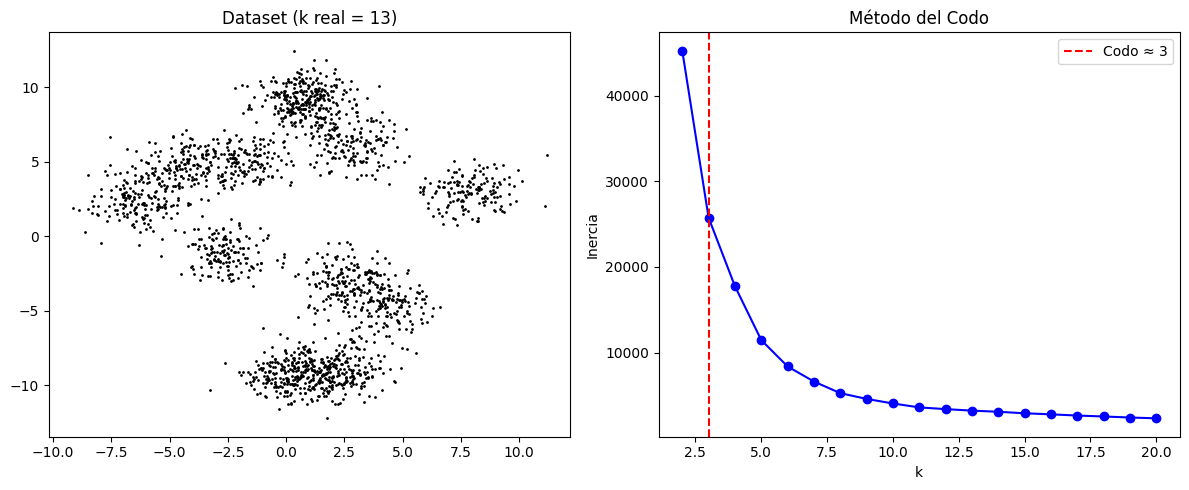

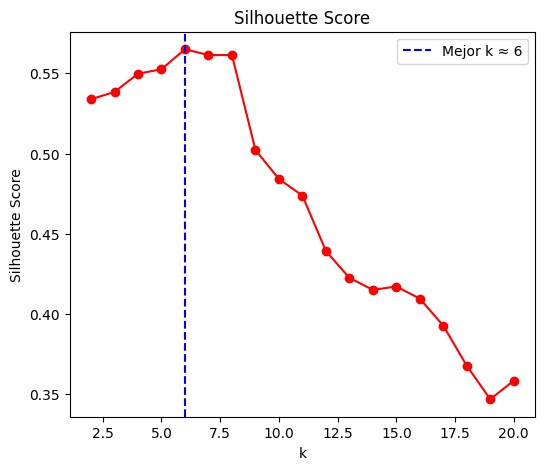

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(X[:, 0], X[:, 1], s=1, c='black')
ax[0].set_title(f"Dataset (k real = {k_real})")

ax[1].plot(rango_k, inercias, 'bo-')
ax[1].axvline(k_codo, color='red', linestyle='--', label=f'Codo ≈ {k_codo}')
ax[1].set_xlabel("k")
ax[1].set_ylabel("Inercia")
ax[1].set_title("Método del Codo")
ax[1].legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(rango_k, silhouette_scores, 'ro-')
plt.axvline(k_silhouette, color='blue', linestyle='--',
            label=f'Mejor k ≈ {k_silhouette}')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.legend()
plt.show()

### 4. Funciones Auxiliares de Visualización

Se definen tres funciones reutilizables para graficar los resultados de clustering:

- `plot_data`: representa cada punto del dataset.
- `plot_centroids`: marca los centroides de K-Means con un símbolo distinguible.
- `plot_decision_boundaries`: genera una malla de predicciones para visualizar las fronteras de decisión Voronoi resultantes del modelo.

In [6]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=100, color='white', edgecolor='black')
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=100, color='red')

def plot_decision_boundaries(clusterer, X, resolution=500):
    mins = X.min(axis=0) - 0.5
    maxs = X.max(axis=0) + 0.5

    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="Pastel2")
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5)
    plot_data(X)
    plot_centroids(clusterer.cluster_centers_)

### 5. Comparación: $k$ Real vs. $k$ Estimado

Se entrena K-Means con el $k$ real (conocido por construcción del dataset) y con el $k$ estimado mediante Silhouette. La comparación visual de las fronteras de decisión permite evaluar cuán bien el método de estimación recupera la estructura subyacente de los datos.

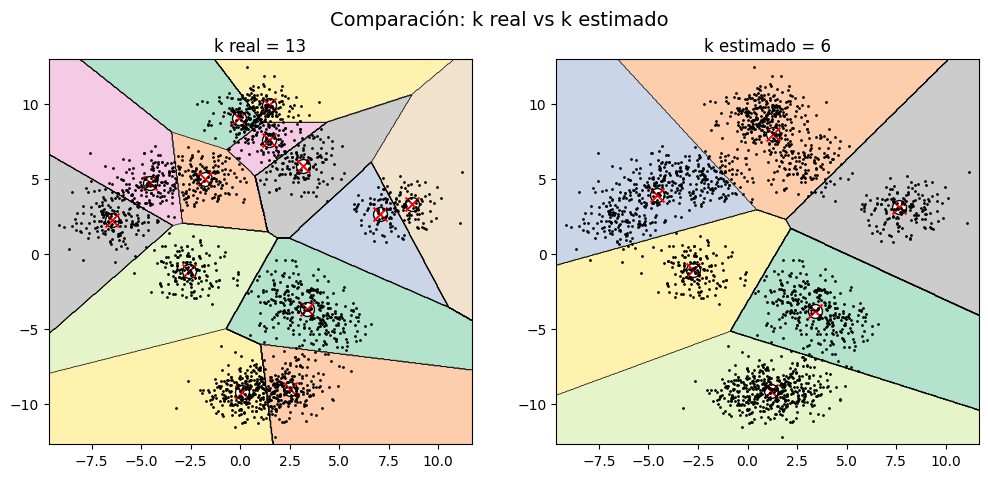

In [7]:
kmeans_real = KMeans(n_clusters=k_real, random_state=42)
kmeans_real.fit(X)

kmeans_estimado = KMeans(n_clusters=k_silhouette, random_state=42)
kmeans_estimado.fit(X)

plt.figure(figsize=(12, 5))

plt.subplot(121)
plot_decision_boundaries(kmeans_real, X)
plt.title(f"k real = {k_real}")

plt.subplot(122)
plot_decision_boundaries(kmeans_estimado, X)
plt.title(f"k estimado = {k_silhouette}")

plt.suptitle("Comparación: k real vs k estimado", fontsize=14)
plt.show()

### 6. Evolución del Algoritmo K-Means

K-Means es un algoritmo iterativo que alterna entre dos pasos: (1) **asignación** de cada punto al centroide más cercano y (2) **actualización** de los centroides como la media de los puntos asignados. Esta visualización muestra cómo evolucionan los clusters y centroides en tres momentos distintos del proceso de convergencia (iteraciones 1, 3 y 6), partiendo desde una inicialización aleatoria.

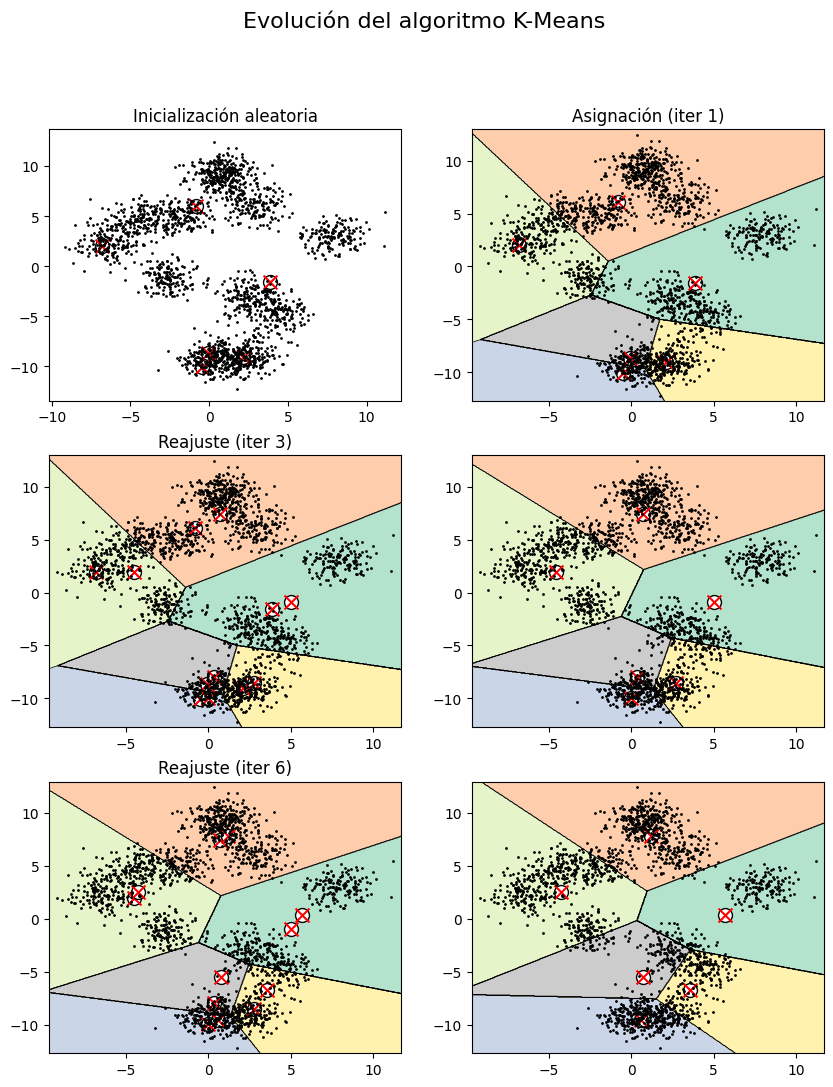

In [8]:
kmeans_iter1 = KMeans(n_clusters=k_silhouette, init="random",
                      n_init=1, max_iter=1, random_state=42)
kmeans_iter2 = KMeans(n_clusters=k_silhouette, init="random",
                      n_init=1, max_iter=3, random_state=42)
kmeans_iter3 = KMeans(n_clusters=k_silhouette, init="random",
                      n_init=1, max_iter=6, random_state=42)

kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 12))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_)
plt.title("Inicialización aleatoria")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X)
plt.title("Asignación (iter 1)")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X)
plot_centroids(kmeans_iter2.cluster_centers_)
plt.title("Reajuste (iter 3)")

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X)
plot_centroids(kmeans_iter3.cluster_centers_)
plt.title("Reajuste (iter 6)")

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X)

plt.suptitle("Evolución del algoritmo K-Means", fontsize=16)
plt.show()

### 7. Resultado Final con K-Means++

La inicialización estándar aleatoria puede llevar a soluciones subóptimas. **K-Means++** mejora esto seleccionando los centroides iniciales de forma proporcional a su distancia al centroide ya elegido más cercano, reduciendo la probabilidad de convergencia a mínimos locales deficientes. Se ejecuta con `n_init=10` para seleccionar el mejor resultado entre 10 inicializaciones distintas.

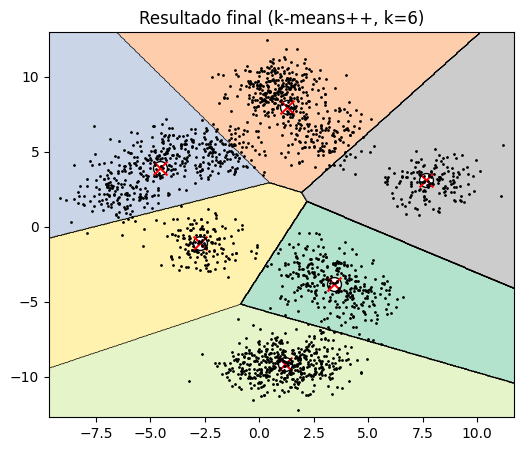

In [9]:
kmeans_plus = KMeans(n_clusters=k_silhouette,
                     init="k-means++", n_init=10, random_state=42)
kmeans_plus.fit(X)

plt.figure(figsize=(6, 5))
plot_decision_boundaries(kmeans_plus, X)
plt.title(f"Resultado final (k-means++, k={k_silhouette})")
plt.show()

### 8. Diagramas de Silueta por Valor de $k$

El diagrama de silueta muestra, para cada muestra, su coeficiente de silueta ordenado por cluster. Un buen particionamiento presenta coeficientes altos y clusters de ancho similar. La línea roja vertical indica el score promedio global.

Se comparan cuatro valores de $k$ relevantes: el estimado como óptimo, el anterior, el siguiente, y el obtenido por el Método del Codo. Esta comparación permite validar visualmente por qué el $k$ seleccionado es superior a sus alternativas.

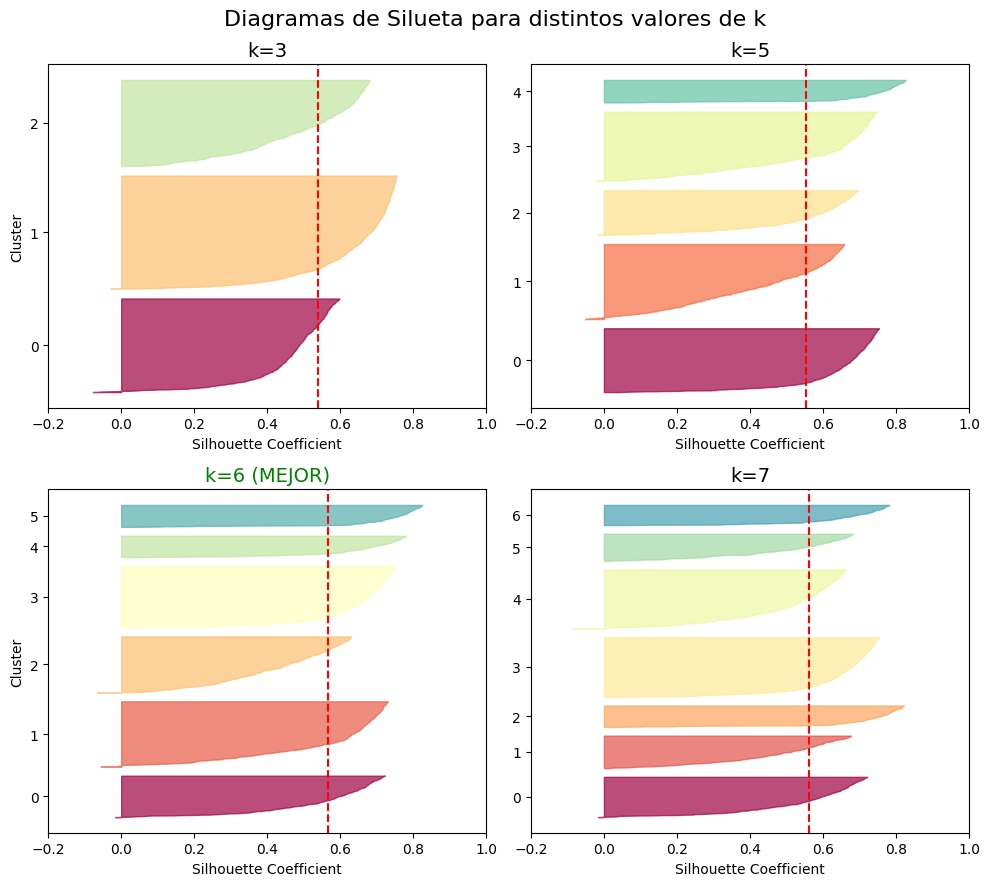

In [10]:
ks_to_plot = [k_silhouette-1, k_silhouette, k_silhouette+1, k_codo]
ks_to_plot = list(set([k for k in ks_to_plot if k > 1 and k <= 20]))

plt.figure(figsize=(10, 9))

for idx, k in enumerate(ks_to_plot):
    plt.subplot(2, 2, idx + 1)

    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    y_pred = model.fit_predict(X)

    silhouette_coefficients = silhouette_samples(X, y_pred)
    avg_score = silhouette_score(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []

    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)

        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))

    plt.axvline(x=avg_score, color="red", linestyle="--")
    plt.xlim([-0.2, 1])

    if k == k_silhouette:
        plt.title(f"k={k} (MEJOR)", fontsize=14, color='green')
    else:
        plt.title(f"k={k}", fontsize=14)

    plt.xlabel("Silhouette Coefficient")
    if idx % 2 == 0:
        plt.ylabel("Cluster")

plt.suptitle("Diagramas de Silueta para distintos valores de k", fontsize=16)
plt.tight_layout()
plt.show()

## Parte 2: Aprendizaje Semi-supervisado con Dataset Skyview

### Contexto y Justificación

**Dataset**: [Skyview: An Aerial Landscape Dataset](https://www.kaggle.com/datasets/ankit1743/skyview-an-aerial-landscape-dataset) (Ankit1743, Kaggle). Contiene imágenes aéreas de paisajes organizadas en categorías (Agriculture, Forest, River, Urban, etc.), capturadas desde perspectiva cenital.

**Clasificar imágenes aéreas se usa en:**

monitoreo ambiental

urbanismo

agricultura inteligente

análisis geográfico

**¿Por qué aprendizaje semi-supervisado?**  
En escenarios reales de visión por computadora, etiquetar imágenes manualmente es costoso y lento. El aprendizaje semi-supervisado aprovecha la gran cantidad de datos sin etiquetar para mejorar un clasificador entrenado con una fracción mínima de etiquetas. En este experimento, se usa clustering para seleccionar una muestra representativa de cada grupo estructural, y solo esas muestras se etiquetan para entrenar el clasificador.

**Extracción de características**:  
Las imágenes se redimensionan a $128 \times 128$ píxeles y se aplana cada una a un vector de dimensión $128 \times 128 \times 3 = 49152$. Posteriormente se aplica PCA para reducir la dimensionalidad a 100 componentes principales, lo que elimina redundancia, acelera el entrenamiento y reduce el ruido en el espacio de features.

### Importación de librerías

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from collections import Counter

### 1. Carga del Dataset

Se recorre la estructura de carpetas del dataset (una carpeta por clase). Cada imagen se lee con OpenCV, se convierte de BGR a RGB, se redimensiona a $128 \times 128$ y se normaliza al rango $[0, 1]$. Las etiquetas numéricas se asignan de acuerdo al índice de la carpeta dentro del directorio ordenado.

In [12]:
DATASET_PATH = "archive/Aerial_Landscapes"
IMG_SIZE = 128

X = []
y = []
class_names = []

for idx, folder in enumerate(sorted(os.listdir(DATASET_PATH))):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        class_names.append(folder)

        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(idx)

X = np.array(X) / 255.0
y = np.array(y)

print("Total imágenes:", X.shape)
print("Total clases:", len(class_names))

Total imágenes: (12000, 128, 128, 3)
Total clases: 15


### 2. Preprocesamiento: Aplanamiento y Partición

Cada imagen de forma $(128, 128, 3)$ se aplana a un vector de 49152 dimensiones, creando la matriz de features $X_{flat}$. El dataset se divide en tres conjuntos:

- **Entrenamiento** (64% del total): usado para ajustar los modelos.
- **Validación** (16%): reservado para ajuste de hiperparámetros.
- **Prueba** (20%): usado exclusivamente para evaluar el rendimiento final.

X_train: (7680, 49152)


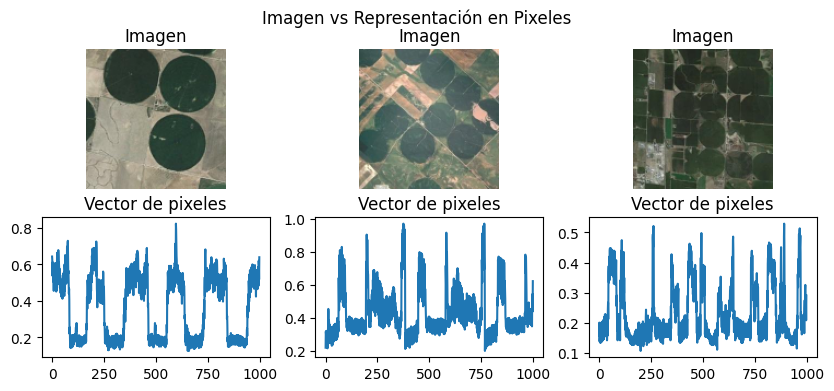

X_test: (2400, 49152)


In [13]:
X_flat = X.reshape(len(X), -1)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)

# --------------------------------------------------
# VISUALIZACIÓN: PIXELES (RAW)
# --------------------------------------------------

# Mostrar 3 imágenes originales vs su vector
num_samples = 3

plt.figure(figsize=(10, 4))

for i in range(num_samples):
    # Imagen original
    plt.subplot(2, num_samples, i + 1)
    plt.imshow(X[i])
    plt.title("Imagen")
    plt.axis('off')

    # Vector de pixeles (como señal)
    plt.subplot(2, num_samples, i + 1 + num_samples)
    plt.plot(X_flat[i][:1000])  # solo primeros 1000 valores
    plt.title("Vector de pixeles")
    
plt.suptitle("Imagen vs Representación en Pixeles")
plt.show()
print("X_test:", X_test.shape)



### 3. Reducción de Dimensionalidad con PCA

El espacio de 49152 dimensiones es computacionalmente prohibitivo para K-Means y Regresión Logística. PCA proyecta los datos a las 100 componentes que capturan la mayor varianza, reduciendo drásticamente el costo computacional sin perder la mayor parte de la información estructural relevante.

El ajuste (`fit`) se realiza **solo sobre el conjunto de entrenamiento** para evitar fuga de información del conjunto de prueba.

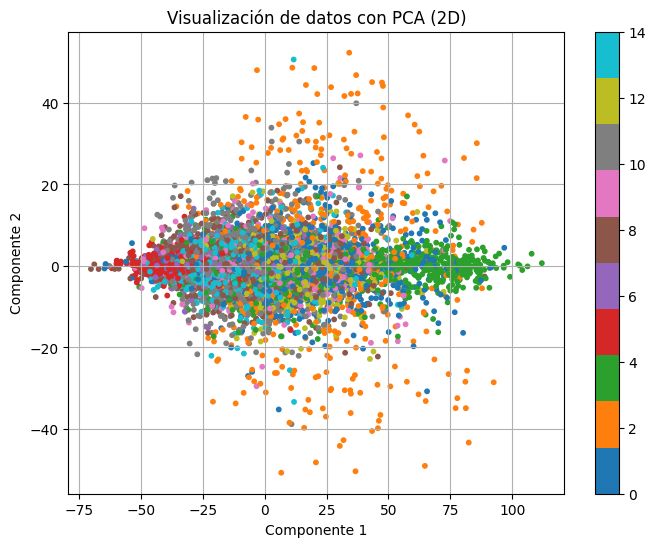

In [14]:
pca = PCA(n_components=100, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)


# --------------------------------------------------
# VISUALIZACIÓN: PCA en 2D
# --------------------------------------------------

# Reducir a 2D SOLO para visualización
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train,
    cmap='tab10',
    s=10
)

plt.colorbar(scatter)
plt.title("Visualización de datos con PCA (2D)")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.grid(True)

plt.show()

### 4. Selección del Número de Clusters ($k$)

Se usa la heurística $k = \lfloor\sqrt{N}\rfloor$ (donde $N$ es el tamaño del conjunto de entrenamiento), ampliamente utilizada como punto de partida razonable cuando no se dispone de criterios más específicos. Se limita a 100 para mantener el costo computacional del clustering bajo control.

In [15]:
k = int(np.sqrt(len(X_train)))
k = min(k, 100)  # límite razonable

print(f"Usando k = {k}")

Usando k = 87


### 5. Clustering sobre el Espacio PCA y el Espacio completo

Se aplica K-Means sobre las representaciones PCA del conjunto de entrenamiento. El resultado es una asignación de cada imagen a un cluster y una matriz de distancias `X_dist` (shape: $N_{train} \times k$), donde cada entrada $(i, j)$ indica la distancia de la muestra $i$ al centroide $j$.

In [16]:
kmeans_raw = KMeans(n_clusters=k, random_state=42, n_init=10)
X_dist_raw = kmeans_raw.fit_transform(X_train)

kmeans_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
X_dist_pca = kmeans_pca.fit_transform(X_train_pca)

### 6. Selección de Muestras Representativas

Para cada cluster se selecciona la imagen más cercana a su centroide (el `argmin` por columna de `X_dist`). Estas $k$ imágenes son las más representativas de su grupo estructural y son las únicas que se etiquetan manualmente en el esquema semi-supervisado. El resto del conjunto de entrenamiento permanece sin etiquetar.

In [17]:
idxs_raw = np.argmin(X_dist_raw, axis=0)
idxs_pca = np.argmin(X_dist_pca, axis=0)

X_rep_raw = X_train[idxs_raw]
y_rep_raw = y_train[idxs_raw]

X_rep_pca = X_train_pca[idxs_pca]
y_rep_pca = y_train[idxs_pca]

### 7. Visualización de las Imágenes Representativas

Se visualizan las imágenes seleccionadas como representativas de cada cluster. Estas imágenes son las que en un caso real requeriría etiquetar un experto humano, de modo que la calidad de la selección tiene un impacto directo en el rendimiento del clasificador posterior.

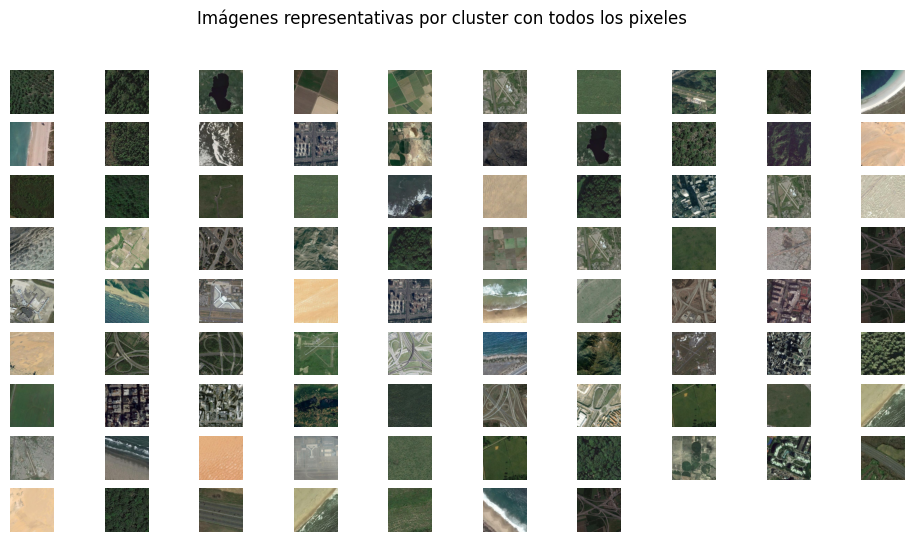

In [18]:
plt.figure(figsize=(12, 6))
cols = 10
rows = int(np.ceil(k / cols))

for i, idx in enumerate(idxs_raw):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[idx].reshape(IMG_SIZE, IMG_SIZE, 3))
    plt.axis('off')

plt.suptitle("Imágenes representativas por cluster con todos los pixeles")
plt.show()

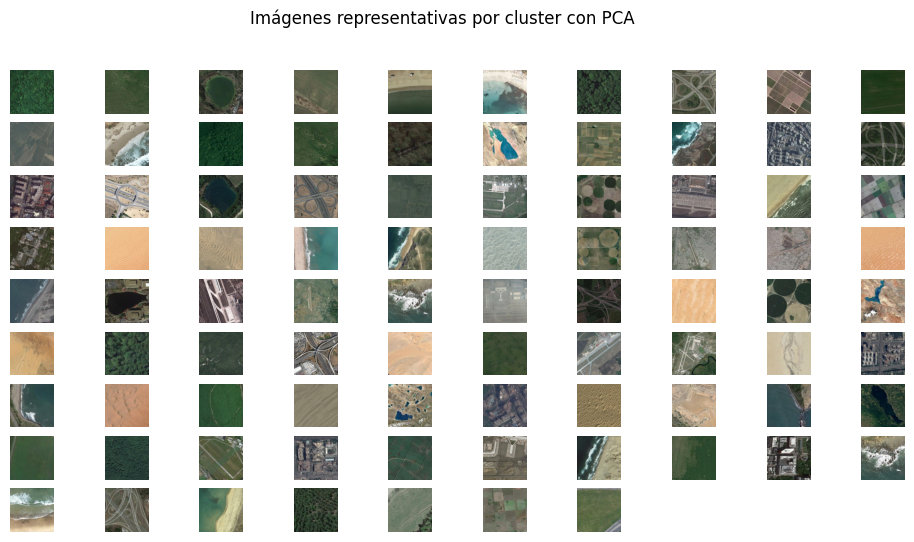

In [19]:
plt.figure(figsize=(12, 6))
cols = 10
rows = int(np.ceil(k / cols))

for i, idx in enumerate(idxs_pca):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(X[idx].reshape(IMG_SIZE, IMG_SIZE, 3))
    plt.axis('off')

plt.suptitle("Imágenes representativas por cluster con PCA")
plt.show()

### 8. Modelo Semi-supervisado: Regresión Logística sobre Representativos

Se entrena una Regresión Logística utilizando únicamente las $k$ muestras representativas etiquetadas. Este es el núcleo del enfoque semi-supervisado: un clasificador competitivo entrenado con una fracción mínima de datos etiquetados, seleccionados de forma inteligente mediante clustering.

In [20]:
# Pixeles completos
log_reg_raw = LogisticRegression(max_iter=5000, random_state=42)
log_reg_raw.fit(X_rep_raw, y_rep_raw)

y_pred_raw = log_reg_raw.predict(X_test)
acc_raw = accuracy_score(y_test, y_pred_raw)



# PCA

log_reg_pca = LogisticRegression(max_iter=5000, random_state=42)
log_reg_pca.fit(X_rep_pca, y_rep_pca)

y_pred_pca = log_reg_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

### 9. Transformación PCA de las Muestras Representativas

Antes de alimentar las muestras representativas al clasificador, se proyectan al mismo espacio PCA usado para el conjunto de entrenamiento. Es fundamental usar el `transform` del PCA ya ajustado (no volver a hacer `fit`) para garantizar consistencia entre los espacios.

In [21]:
# Pixeles
log_reg_raw.fit(X_rep_raw, y_rep_raw)

# PCA
log_reg_pca.fit(X_rep_pca, y_rep_pca)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

### 10. Baseline Aleatorio

Como punto de referencia, se entrena un clasificador equivalente pero con $k$ muestras seleccionadas **aleatoriamente** del conjunto de entrenamiento. Comparar este baseline con el modelo semi-supervisado permite cuantificar el beneficio real de la selección estratégica basada en clustering.

In [22]:
idxs_random = np.random.choice(len(X_train), k, replace=False)

X_rand_pca = pca.transform(X_train[idxs_random])

log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_rand_pca, y_train[idxs_random])

y_pred_rand = log_reg.predict(X_test_pca)
acc_rand = accuracy_score(y_test, y_pred_rand)

### 11. Propagación de Etiquetas (Pseudo-labeling)

Se extiende la cobertura del modelo asignando a cada muestra sin etiquetar la clase mayoritaria de su cluster (determinada por las etiquetas reales disponibles dentro del cluster). Esta técnica se denomina **propagación de etiquetas** o pseudo-labeling.

Se usa el voto por mayoría en lugar de la etiqueta del representativo, lo que es más robusto ante clusters impuros. El clasificador resultante entrena sobre todo el conjunto de entrenamiento con estas etiquetas propagadas, aprovechando la totalidad de los datos no etiquetados.

In [ ]:
# pixeles

y_train_prop_raw = np.empty(len(X_train))

for i in range(k):
    mask = (kmeans_raw.labels_ == i)
    if np.sum(mask) > 0:
        y_train_prop_raw[mask] = Counter(y_train[mask]).most_common(1)[0][0]

log_reg_prop_raw = LogisticRegression(max_iter=5000)
log_reg_prop_raw.fit(X_train, y_train_prop_raw)

acc_prop_raw = accuracy_score(y_test, log_reg_prop_raw.predict(X_test))


# PCA

y_train_prop_pca = np.empty(len(X_train))

for i in range(k):
    mask = (kmeans_pca.labels_ == i)
    if np.sum(mask) > 0:
        y_train_prop_pca[mask] = Counter(y_train[mask]).most_common(1)[0][0]

log_reg_prop_pca = LogisticRegression(max_iter=5000)
log_reg_prop_pca.fit(X_train_pca, y_train_prop_pca)

acc_prop_pca = accuracy_score(y_test, log_reg_prop_pca.predict(X_test_pca))

### 12. Resultados Comparativos

Se imprime la accuracy de los tres enfoques:

- **Semi-supervisado (representativos)**: clasificador entrenado con las $k$ muestras más representativas.
- **Aleatorio (baseline)**: clasificador entrenado con $k$ muestras elegidas al azar.
- **Propagado (pseudo-labeling)**: clasificador entrenado sobre todo el conjunto con etiquetas propagadas por cluster.

In [ ]:
print("\n--- RESULTADOS ---")
print(f"Raw (pixeles completos): {acc_raw:.4f}")
print(f"PCA:                      {acc_pca:.4f}")
print(f"Propagado Raw:           {acc_prop_raw:.4f}")
print(f"Propagado PCA:           {acc_prop_pca:.4f}")


--- RESULTADOS ---
Raw (pixeles completos): 0.1808
PCA:                      0.2687
Propagado Raw:           0.2871
Propagado PCA:           0.3296


### 13. Gráficos Comparativos de Accuracy

Se visualizan los resultados mediante gráficos de barras verticales y horizontales. Las barras permiten comparar de forma directa el impacto de cada estrategia de selección y etiquetado.

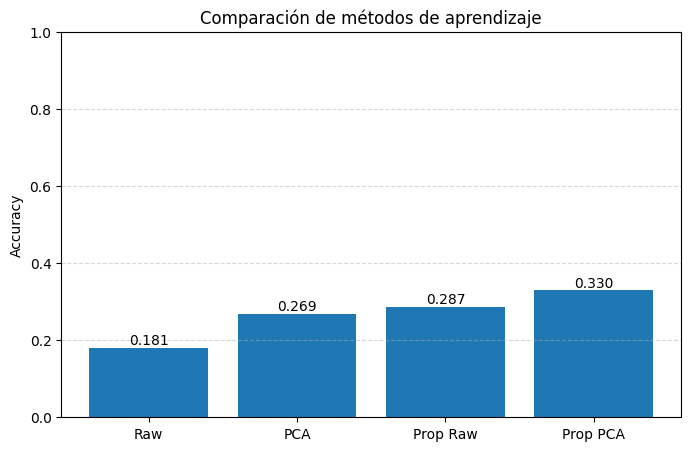

In [ ]:
metodos = [
    "Raw",
    "PCA",
    "Prop Raw",
    "Prop PCA"
]

accuracies = [
    acc_raw,
    acc_pca,
    acc_prop_raw,
    acc_prop_pca
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metodos, accuracies)

# Mostrar valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{height:.3f}",
             ha='center', va='bottom')

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparación de métodos de aprendizaje")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Parte 3: Aprendizaje Activo

### Fundamento

El **Aprendizaje Activo** (Active Learning) es una extensión del enfoque semi-supervisado que itera estratégicamente: en lugar de etiquetar muestras al azar o solo las representativas de clusters, se seleccionan las muestras sobre las que el modelo actual tiene mayor **incertidumbre**. En cada iteración, un oráculo humano etiqueta esas muestras y el modelo se reentrenada, mejorando en los puntos críticos del espacio de decisión.

En este experimento, se parte del modelo con etiquetas propagadas (el más informado del paso anterior) y se aplica **muestreo por entropía máxima** como criterio de incertidumbre:

$$H(x) = -\sum_{c} p(c \mid x) \log p(c \mid x)$$

Una entropía alta indica que el modelo distribuye la probabilidad de forma uniforme entre clases, lo que señala baja confianza. Las muestras con mayor entropía son las candidatas prioritarias para etiquetado humano.

### 14. Ciclo de Active Learning

El flujo completo del ciclo activo implementado es:

1. Calcular las probabilidades de predicción del modelo propagado sobre todo el conjunto de entrenamiento.
2. Computar la entropía de Shannon por muestra.
3. Seleccionar las $k_{active}$ muestras más inciertas.
4. Simular el etiquetado humano asignando las etiquetas reales a esas muestras.
5. Corregir las etiquetas propagadas con las etiquetas reales en los índices seleccionados.
6. Reentrenar el clasificador con el conjunto corregido.
7. Evaluar en el conjunto de prueba.

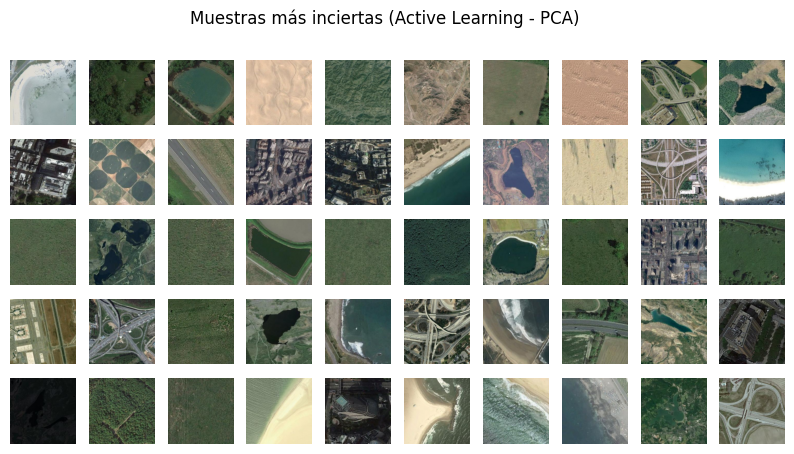

Accuracy (Active Learning - PCA): 0.3321


KeyboardInterrupt: 

In [ ]:
# 14. ACTIVE LEARNING (SOBRE PCA)

# Usamos pipeline PCA
X_train_subset = X_train_pca
y_train_subset = y_train
y_train_prop = y_train_prop_pca.copy()

# 1. Probabilidades del modelo propagado (PCA)
probas = log_reg_prop_pca.predict_proba(X_train_subset)

# 2. ENTROPÍA (incertidumbre)
entropy = -np.sum(probas * np.log(probas + 1e-10), axis=1)

# 3. Ordenar por incertidumbre
sorted_ixs = np.argsort(-entropy)

k_active = min(100, len(X_train_subset))

# 4. Selección de muestras más inciertas
selected_idxs = sorted_ixs[:k_active]

# 5. VISUALIZACIÓN
plt.figure(figsize=(10, 5))
for i, idx in enumerate(selected_idxs[:50]):
    plt.subplot(5, 10, i + 1)
    plt.imshow(X[idx])  # usar X original
    plt.axis('off')

plt.suptitle("Muestras más inciertas (Active Learning - PCA)")
plt.show()

# Simulación de etiquetado humano
y_correct = y_train_subset[selected_idxs]

# Corrección de etiquetas
y_train_active = y_train_prop.copy()
y_train_active[selected_idxs] = y_correct

# 8. Reentrenamiento
log_reg_active = LogisticRegression(max_iter=5000, random_state=42)
log_reg_active.fit(X_train_subset, y_train_active)

# 9. Evaluación
y_pred_active = log_reg_active.predict(X_test_pca)
acc_active = accuracy_score(y_test, y_pred_active)

print(f"Accuracy (Active Learning - PCA): {acc_active:.4f}")


# ACTIVE LEARNING (RAW)

probas_raw = log_reg_prop_raw.predict_proba(X_train)

entropy_raw = -np.sum(probas_raw * np.log(probas_raw + 1e-10), axis=1)

sorted_ixs_raw = np.argsort(-entropy_raw)
selected_idxs_raw = sorted_ixs_raw[:k_active]

y_correct_raw = y_train[selected_idxs_raw]

y_train_active_raw = y_train_prop_raw.copy()
y_train_active_raw[selected_idxs_raw] = y_correct_raw

log_reg_active_raw = LogisticRegression(max_iter=5000)
log_reg_active_raw.fit(X_train, y_train_active_raw)

acc_active_raw = accuracy_score(y_test, log_reg_active_raw.predict(X_test))

print(f"Accuracy (Active Learning - RAW): {acc_active_raw:.4f}")


print("\n ACTIVE LEARNING ")
print(f"PCA: {acc_active:.4f}")
print(f"RAW: {acc_active_raw:.4f}")

### Comparación Final: Todos los Métodos

Se añade Active Learning a la comparación acumulada. El gráfico final muestra el impacto incremental de cada estrategia, desde el baseline aleatorio hasta el ciclo activo. La mejora entre el pseudo-labeling y el Active Learning cuantifica el beneficio de corregir selectivamente las etiquetas más ruidosas del conjunto propagado.

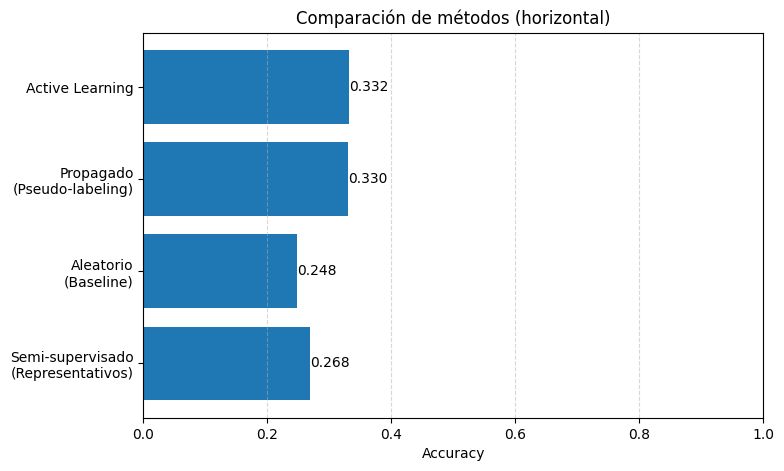

In [ ]:
metodos.append("Active Learning")
accuracies.append(acc_active)

plt.figure(figsize=(8, 5))
bars = plt.barh(metodos, accuracies)

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2,
             f"{width:.3f}",
             va='center')

plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Comparación de métodos (horizontal)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()